In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
import random

In [3]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int
    

In [4]:
def greeting_node(state: AgentState) -> AgentState:
    print(f"Hello {state['name']}! Let's start the L00p.")
    state['counter'] = 0
    return state

def random_node(state: AgentState) -> AgentState:
    random_number = random.randint(1, 100)
    state['number'].append(random_number)
    print(f"Random number generated: {random_number}")
    state['counter'] += 1
    return state

def should_continue(state: AgentState) -> bool:
    """Function to decide what to do next"""
    if state['counter'] < 5:
        return "loop"
    else:
        return "end"




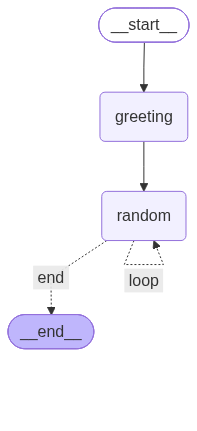

In [7]:
graph = StateGraph(AgentState)
graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)

graph.add_edge(START, "greeting")
graph.add_edge("greeting", "random")
graph.add_conditional_edges("random", should_continue, {
    "loop": "random",
    "end": END
})


graph.compile()
